# Model Review

## Created By: David Hatchett
## Created: 2026-02-10

this is doign the test loop to verify how good the model is working. Also we are creating graphs for the paper.

In [1]:
import board_game_rec as bgr 
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import json

import torchmetrics

from torch.utils.data import DataLoader



from matplotlib import pyplot as plt 

In [2]:
### set up the device for the model. I got this from a search to the best way to set this up.

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): 
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
## load the data from the json file
## this way we can create graphs on the training results.
rslt_hist = pd.DataFrame(json.load(open('model/history.json','r',encoding='utf-8')))

In [4]:
rslt_hist

,train_loss,validation_loss,train_nrmse,train_mae,train_r2,validation_nrmse,validation_mae,validation_r2,learning_rate
0,2.001840,1.600427,0.155714,1.060425,0.197288,0.140630,0.935868,0.358506,0.001
1,1.603161,1.567585,0.140797,0.937614,0.357489,0.139180,0.925637,0.371671,0.001
2,1.571659,1.557343,0.139409,0.926577,0.370083,0.138723,0.921729,0.375822,0.001
3,1.562458,1.552769,0.139000,0.923845,0.373764,0.138519,0.921038,0.377645,0.001
4,1.559193,1.548751,0.138841,0.922846,0.375113,0.138340,0.919546,0.379231,0.001
5,1.557259,1.547305,0.138777,0.922346,0.375872,0.138275,0.917256,0.379812,0.001
6,1.556351,1.547019,0.138744,0.921945,0.376228,0.138264,0.920769,0.379911,0.001
7,1.555303,1.548952,0.138679,0.921710,0.376652,0.138346,0.916154,0.379155,0.001
8,1.554315,1.549007,0.138673,0.921495,0.377043,0.138347,0.915761,0.379104,0.001
9,1.553562,1.540765,0.138635,0.921338,0.377345,0.137981,0.915515,0.382396,0.001


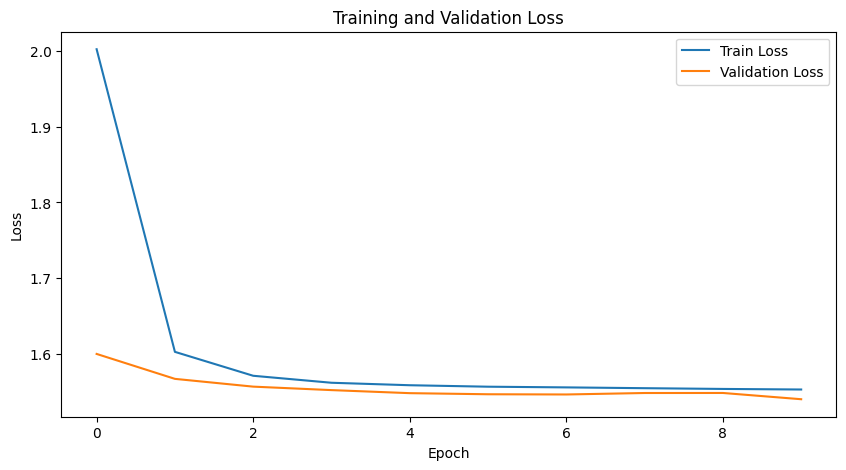

In [5]:
## creae a graph of the training and validation loss
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(rslt_hist['train_loss'], label='Train Loss')
ax.plot(rslt_hist['validation_loss'], label='Validation Loss')
ax.legend()
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
plt.show()




In [6]:
### test the model on the test set
df = pd.read_csv('data/prep_data/test_data.csv')
df['category_indices'] = df['category_indices'].apply(ast.literal_eval)
df['mechanic_indices'] = df['mechanic_indices'].apply(ast.literal_eval)

test_dataset = bgr.UserGameDataSet(df)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=0, collate_fn=bgr.collate_fn)

In [7]:
#Get rid of extra data
del (df,test_dataset)

In [8]:
config = bgr.setup_config("config/config.json")
user_encoder, game_encoder, category_encoder, mechanic_encoder = bgr.get_encoders(config)

### Set up the model
model = bgr.BoardGameRecommender(
    num_users=len(user_encoder),
    num_games=len(game_encoder),
    num_categories=len(category_encoder),
    num_mechanics=len(mechanic_encoder),
    dropout_rate=0.2,
)

model.load_state_dict(torch.load('model/board_game_recommender10.pt', map_location=device))
model.to(device)  # move model to the correct device after loading weights
model.eval()

BoardGameRecommender(
  (user_embedding): Embedding(555482, 128)
  (game_embedding): Embedding(25707, 32)
  (category_embedding): EmbeddingBag(84, 8, mode='mean')
  (mechanic_embedding): EmbeddingBag(192, 16, mode='mean')
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=189, out_features=189, bias=True)
  (fc2): Linear(in_features=189, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

In [9]:
### set loop for test


nrmse_list = []
mae_list = []
r2_list = []


model.eval()

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        x = model(
                    user_id = batch["users_id"],
                    game_id = batch["game_id"],
                    avg_usr_rating = batch["avg_usr_rating"],
                    avg_usr_weight = batch["avg_usr_weight"],
                    bayes_average = batch["bayes_average"],
                    age = batch["age"],
                    game_owners = batch["game_owners"],
                    category_indices = batch["category_indices"],
                    category_offsets = batch["category_offsets"],
                    mechanic_indices = batch["mechanic_indices"],
                    mechanic_offsets = batch["mechanic_offsets"],
        ).to(device)
        out_true = batch['user_rating'].to(torch.float32)
        out_pred = x.squeeze()

        nrmse_list.append(torchmetrics.functional.regression.normalized_root_mean_squared_error(out_pred, out_true, normalization='range',num_outputs=1).cpu())
        mae_list.append(torchmetrics.functional.mean_absolute_error(out_pred, out_true).cpu())
        r2_list.append(torchmetrics.functional.r2_score(out_pred, out_true).cpu())



In [10]:
#Get the results test loop.
print(f'nrmse mean: {np.mean(nrmse_list)}')
print(f'nrmse max: {np.max(nrmse_list)}')
print(f'nrmse min: {np.min(nrmse_list)}')
print(f'mae mean: {np.mean(mae_list)}')
print(f'mae max: {np.max(mae_list)}')
print(f'mae min: {np.min(mae_list)}')
print(f'r2 mean: {np.mean(r2_list)}')
print(f'r2 max: {np.max(r2_list)}')
print(f'r2 min: {np.min(r2_list)}')

nrmse mean: 0.1379585564136505
nrmse max: 0.15714721381664276
nrmse min: 0.11793128401041031
mae mean: 0.9151883125305176
mae max: 1.0245321989059448
mae min: 0.8113149404525757
r2 mean: 0.38310080766677856
r2 max: 0.5048679113388062
r2 min: 0.2508365511894226
